In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

In [ ]:
from sklearn.datasets import load_breast_cancer, fetch_openml
from sklearn.model_selection import train_test_split

import shap 

from tabpfn_extensions import TabPFNClassifier, interpretability, TabPFNRegressor
from tabpfn_extensions.interpretability import shapiq, shapiq_to_shap_explanation

In [14]:
data = load_breast_cancer()
X = data.data
y = data.target 
feature_names = data.feature_names

X, y, feature_names = X[:100, :10], y[:100], feature_names[:10]

In [16]:
clf = TabPFNClassifier(n_estimators=1)

result = interpretability.feature_selection.feature_selection(
    estimator=clf,
    X=X,
    y=y,
    n_features_to_select=2,
    feature_names=list(feature_names)
)

Feature selection: direction='forward', cv=5, scoring=default, n_features_to_select=2
Baseline CV score on all 10 features: 0.9200 ± 0.0600


  round 1/2: picked feature np.str_('mean concave points'), cv score = 0.9200
  round 2/2: picked feature np.str_('mean texture'), cv score = 0.9300
Selected 2 feature(s): [np.str_('mean texture'), np.str_('mean concave points')]
CV score on selected features: 0.9300 ± 0.0510


In [17]:
print(result.selected_names)


[np.str_('mean texture'), np.str_('mean concave points')]


In [18]:
print(result)

FeatureSelectionResult(selector=_VerboseSFS(estimator=TabPFNClassifier(n_estimators=1), n_features_to_select=2), support_mask=array([False,  True, False, False, False, False, False,  True, False,
       False]), selected_indices=[1, 7], selected_names=[np.str_('mean texture'), np.str_('mean concave points')], baseline_score_mean=0.9199999999999999, baseline_score_std=0.060000000000000005, selected_score_mean=0.9299999999999999, selected_score_std=0.05099019513592784)


In [20]:
credit = fetch_openml('credit-g', version = 1, as_frame = False)
X, y, feature_names = credit.data, credit.target, list(credit.feature_names)

In [23]:
X_train, X_test, y_train, _ = train_test_split(
    X,
    y,
    train_size=800,
    test_size=200,
    random_state=0,
)

In [26]:
clf = TabPFNClassifier(fit_mode="fit_with_cache")
clf.fit(X_train, y_train)

explainer = shapiq.get_tabpfn_imputation_explainer(
    model=clf,
    data=X_train,
    index="SV",
    max_order=1,
)

/opt/anaconda3/lib/python3.13/site-packages/shapiq/imputer/baseline_imputer.py:90: UserWarning: Feature 0 is not numerical. Adding it to categorical features.
  self.init_background(self.data)
/opt/anaconda3/lib/python3.13/site-packages/shapiq/imputer/baseline_imputer.py:90: UserWarning: Feature 2 is not numerical. Adding it to categorical features.
  self.init_background(self.data)
/opt/anaconda3/lib/python3.13/site-packages/shapiq/imputer/baseline_imputer.py:90: UserWarning: Feature 3 is not numerical. Adding it to categorical features.
  self.init_background(self.data)
/opt/anaconda3/lib/python3.13/site-packages/shapiq/imputer/baseline_imputer.py:90: UserWarning: Feature 5 is not numerical. Adding it to categorical features.
  self.init_background(self.data)
/opt/anaconda3/lib/python3.13/site-packages/shapiq/imputer/baseline_imputer.py:90: UserWarning: Feature 6 is not numerical. Adding it to categorical features.
  self.init_background(self.data)
/opt/anaconda3/lib/python3.13/site-

In [29]:
n_explain = 30
X_explain = X_test[:n_explain]

print(f"Computing Shapley values for {n_explain} rows...")
explanation = shapiq_to_shap_explanation(
    explainer,
    X_explain,
    budget=256,
    feature_names=feature_names,
)

Computing Shapley values for 30 rows...


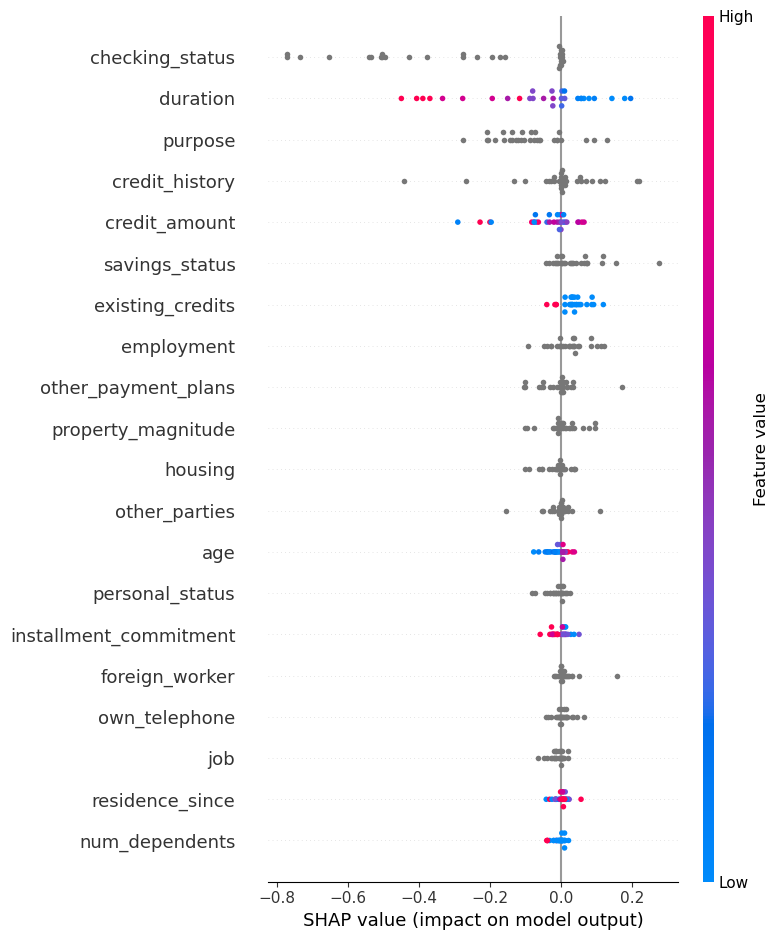

In [31]:
shap.summary_plot(explanation)

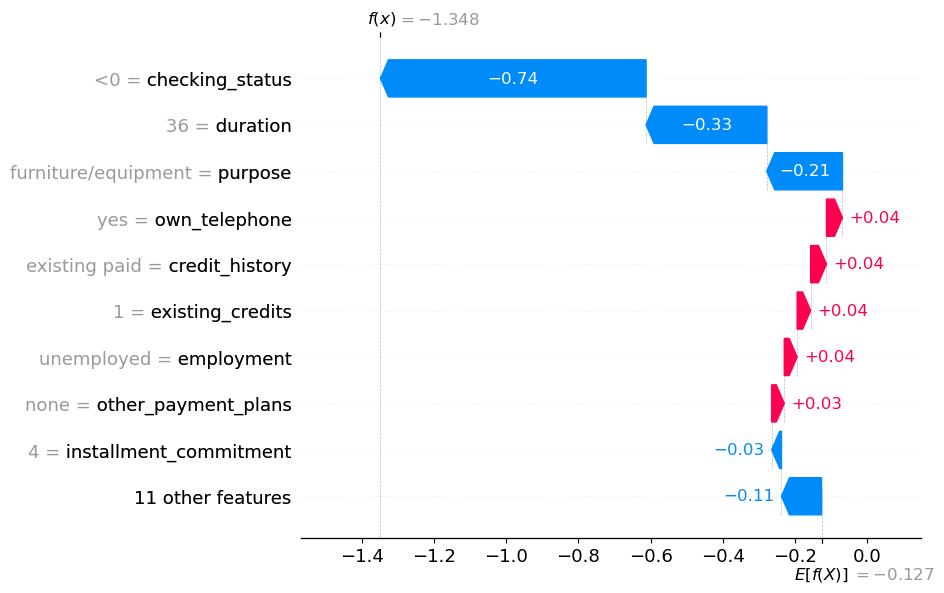

In [33]:
shap.plots.waterfall(explanation[0])

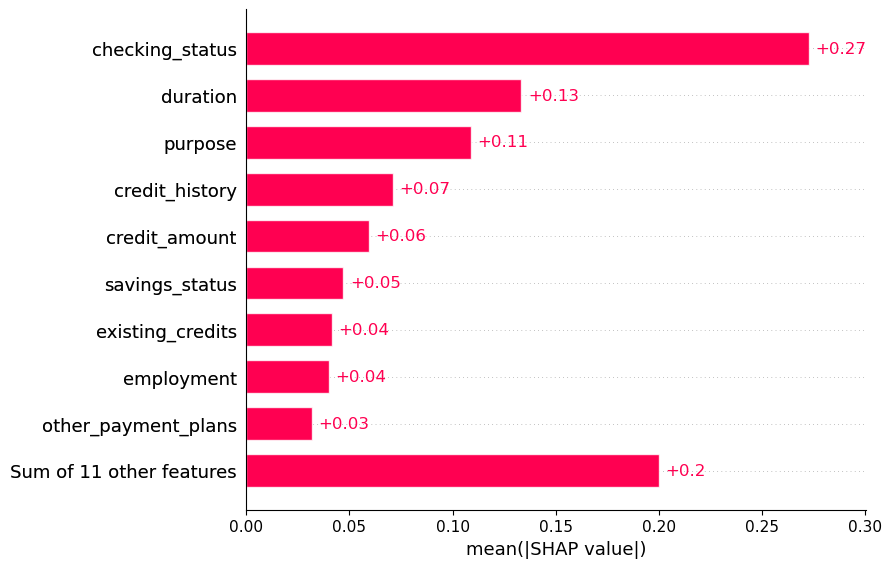

In [32]:
shap.plots.bar(explanation)

In [36]:
print(explanation[-2])

.values =
array([ 0.00030739,  0.00955012,  0.05546854, -0.05912203, -0.03261844,
        0.04116927,  0.0239592 ,  0.00414523, -0.01720195, -0.00093595,
        0.00491143, -0.00041435,  0.00761969,  0.004438  , -0.00190129,
        0.03240931,  0.00031249, -0.0023918 ,  0.01347505,  0.00035731])

.base_values =
np.float64(-0.12706249952316284)

.data =
array(['no checking', 15, 'critical/other existing credit', 'new car',
       5045, 'no known savings', '>=7', 1, 'female div/dep/mar', 'none',
       4, 'car', 59, 'none', 'own', 1, 'skilled', 1, 'yes', 'yes'],
      dtype=object)


In [37]:
print(explanation[-3])

.values =
array([-2.38486510e-01,  1.43064128e-01,  7.06793141e-02, -7.60390970e-02,
       -3.32022223e-02, -1.22425063e-02,  3.79255315e-02, -2.72850393e-02,
        3.75711031e-03, -1.11049752e-03,  3.52402631e-03, -1.53709954e-02,
       -1.58542099e-03, -1.27448877e-03, -5.25609213e-02,  1.07433594e-02,
       -3.02124909e-05,  1.15505519e-02,  6.37315247e-02,  2.16871205e-02])

.base_values =
np.float64(-0.12706249952316284)

.data =
array(['0<=X<200', 9, 'critical/other existing credit',
       'furniture/equipment', 1919, '<100', '4<=X<7', 4, 'male single',
       'none', 3, 'car', 35, 'none', 'rent', 1, 'skilled', 1, 'yes',
       'yes'], dtype=object)


In [38]:
print(len(explanation))

30
